# Notebook di test

In [3]:

import numpy as np
import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import matplotlib.pyplot as plt
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values

from scipy.optimize import least_squares

In [4]:
%matplotlib widget
plt.close('all')

computing T-matrices for
channel = [{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]
Tlab = 1e-06 MeV
Tlab = 0.1 MeV
Tlab = 0.2 MeV
Tlab = 0.3 MeV
Tlab = 0.4 MeV
Tlab = 0.5 MeV
Tlab = 0.6 MeV
Tlab = 0.7 MeV
Tlab = 0.8 MeV
Tlab = 0.9 MeV
Tlab = 1.0 MeV
Tlab = 2 MeV
Tlab = 3 MeV
Tlab = 4 MeV
Tlab = 5 MeV
Tlab = 6 MeV
Tlab = 7 MeV
Tlab = 8 MeV
Tlab = 9 MeV
Tlab = 10 MeV
Tlab = 11 MeV
Tlab = 12 MeV
Tlab = 13 MeV
Tlab = 14 MeV
Tlab = 15 MeV
Tlab = 16 MeV
Tlab = 17 MeV
Tlab = 18 MeV
Tlab = 19 MeV
Tlab = 20 MeV
Tlab = 21 MeV
Tlab = 22 MeV
Tlab = 23 MeV
Tlab = 24 MeV
Tlab = 25 MeV
Tlab = 26 MeV
Tlab = 27 MeV
Tlab = 28 MeV
Tlab = 29 MeV
Tlab = 30 MeV
Tlab = 40 MeV
Tlab = 50 MeV
Tlab = 60 MeV
Tlab = 70 MeV
Tlab = 80 MeV
Tlab = 90 MeV
Tlab = 100 MeV


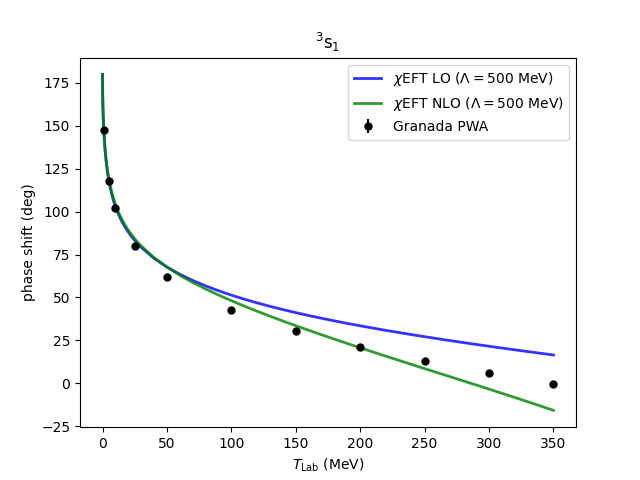

In [5]:


# initialize an object for computing T-matrices, phase shifts
# Np is the number of quadrature points used in the solution of the LS equation.
# the mesh_type defaults to 'gauleg_infinite' if nothing else. Use this for scattering.
# (use gauleg_finite for bound states).
nn = nn_studio.nn_studio(jmin=0,jmax=1,tzmin=0,tzmax=0,Np=30)

# define the lab neutron-proton kinetic energies that you want to analyze (denser for low T in this case)
nn.Tlabs = [1e-6] + [x/10 for x in np.arange(1,11,1)]+[x for x in np.arange(2,31,1)] + [x for x in np.arange(40,360,10)]
## you can inspect results for the channels <ll s j || l s j> in your basis
_,selected_channel = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)

#get the 'empirical' granada values for plotting
exp_phases = granada.delta_3S1
err_phases = granada.delta_3S1_errors

# initialize an object for the chiral interaction (isospin symmetric LO, NLO in WPC available)
potential_lo = chiral_potential.two_nucleon_potential('LO',Lambda=500.0)
potential_nlo = chiral_potential.two_nucleon_potential('NLO',Lambda=500.0)

# give the potential to the nn-analyzer
nn.V = potential_lo
# give the LECS to the potential (via the nn-analyzer)
nn.lecs = lec_values.lo_lecs
# solve the Lippmann-Schwinger equation and compute phase shifts (for selected_channel)
nn.compute_Tmtx(selected_channel,verbose=True)
delta_lo = nn.phase_shifts[0][:,0]

#now solve for NLO
nn.V = potential_nlo
nn.lecs = lec_values.nlo_lecs
nn.compute_Tmtx(selected_channel,verbose=True)
delta_nlo = nn.phase_shifts[0][:,0]

# plot the result
plt.errorbar(granada.Tlabs,exp_phases, yerr=err_phases,label = 'Granada PWA', color='black',ls='none',marker='o',markersize=5.)
plt.plot(nn.Tlabs,delta_lo, label = r'$\chi$EFT LO ($\Lambda=500$ MeV)',color='blue',alpha=0.8,lw=2)
plt.plot(nn.Tlabs,delta_nlo, label = r'$\chi$EFT NLO ($\Lambda=500$ MeV)',color='green',alpha=0.8,lw=2)
plt.xlabel(r'$T_\mathrm{Lab}$ (MeV)')
plt.ylabel(r'phase shift (deg)')
plt.title(r'$^3$s$_1$')
plt.legend()
#plt.savefig('lo_nlo_phases.pdf')
plt.show()



